# TEB-project 

In [1]:
import cv2

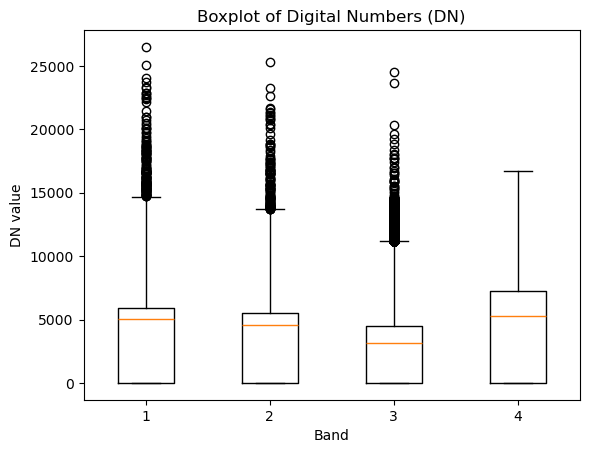

In [55]:
import rasterio
import matplotlib.pyplot as plt

def plot_boxplot(file_path):
    with rasterio.open(file_path) as src:
        fig, ax = plt.subplots()
        band_data = [src.read(i+1).flatten() for i in range(src.count)]
        ax.boxplot(band_data, vert=True)
        ax.set_title("Boxplot of Digital Numbers (DN)")
        ax.set_xlabel("Band")
        ax.set_ylabel("DN value")
        plt.show()

plot_boxplot(r"C:\Users\Jahanvi\Downloads\20240113_065853_42_2477_3B_AnalyticMS\20240113_065853_42_2477_3B_AnalyticMS.tif")


Reflectance Stats:
Band 1: min=0.000000, max=1.000000, mean=0.416514
Band 2: min=0.000000, max=1.000000, mean=0.383924
Band 3: min=0.000000, max=1.000000, mean=0.307059
Band 4: min=0.000000, max=1.000000, mean=0.437432


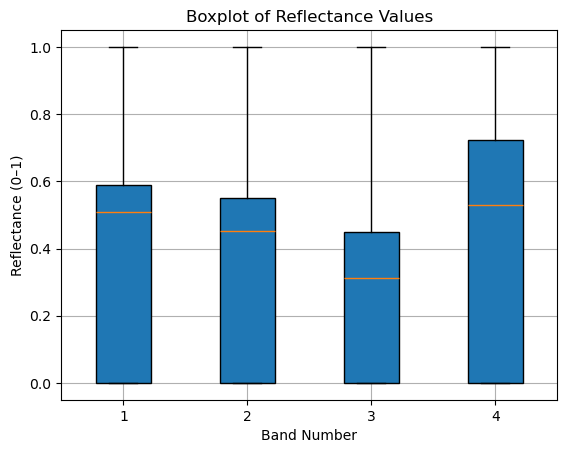

In [56]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Convert DN to Reflectance
def convert_to_reflectance(input_path, output_path, scale_factor=0.0001):
    with rasterio.open(input_path) as src:
        # Copy metadata and update data type to float32
        meta = src.meta.copy()
        meta.update(dtype='float32')

        # Read DN data and convert to reflectance
        dn_data = src.read().astype('float32')  # shape: (bands, rows, cols)
        reflectance = dn_data * scale_factor

        # Optionally clip values to valid reflectance range (0–1)
        reflectance = np.clip(reflectance, 0, 1)

    # Save the reflectance image
    with rasterio.open(output_path, 'w', **meta) as dst:
        dst.write(reflectance)

# Step 2: Plot Boxplot for Reflectance Values
def plot_reflectance_boxplot(file_path):
    with rasterio.open(file_path) as src:
        band_data = []
        print("Reflectance Stats:")
        for i in range(src.count):
            band = src.read(i + 1).flatten()
            band_data.append(band)
            print(f"Band {i+1}: min={np.min(band):.6f}, max={np.max(band):.6f}, mean={np.mean(band):.6f}")

        # Create boxplot
        fig, ax = plt.subplots()
        ax.boxplot(band_data, vert=True, patch_artist=True)
        ax.set_title("Boxplot of Reflectance Values")
        ax.set_xlabel("Band Number")
        ax.set_ylabel("Reflectance (0–1)")
        plt.grid(True)
        plt.show()

# === Usage ===
dn_input_path = r"C:\Users\Jahanvi\Downloads\20240113_065853_42_2477_3B_AnalyticMS\20240113_065853_42_2477_3B_AnalyticMS.tif"
reflectance_output_path = r"ortho_analytic_reflectance1.tif"

# Convert to reflectance and plot
convert_to_reflectance(dn_input_path, reflectance_output_path)
plot_reflectance_boxplot(reflectance_output_path)


In [62]:
file_path = r"E:\subset_20_of_subset_19_of_subset_14_of_subset_0_of_S1A_IW_GRDH_1SDV_20240117T021944_20240117T022009_052140_064D65_B55C_Orb_tnr_Cal_Spk_TC.tif"

we got this histogram for the subset in the snap
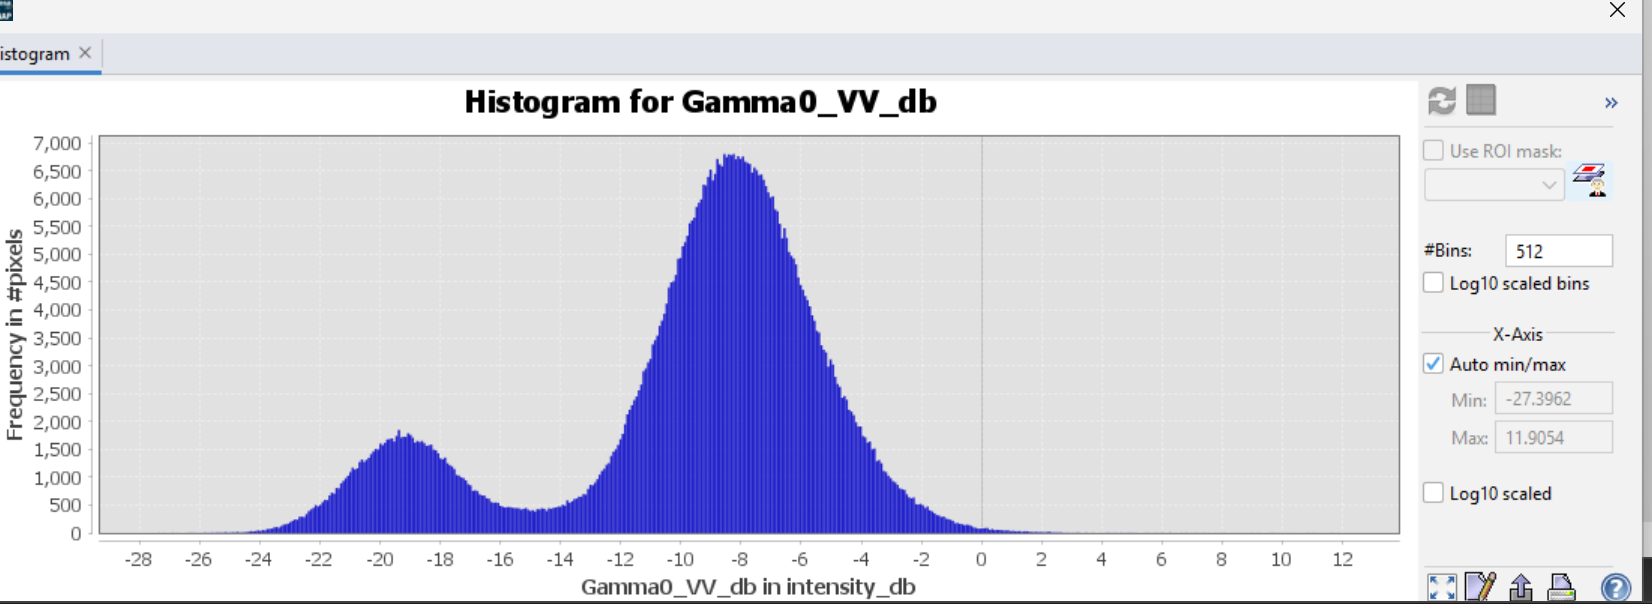

We selected the band **gamma_0** in the process of caliberation because our terrain is hilly(the area of Anatavario). 
In case of plain we could have chosen the band as **sigma_0**.
The two peaks are extremely well separated:
One peak around -19 dB (smaller → likely water),
One peak around -8 dB (larger → likely land, vegetation, or urban areas).
 Two distinct classes → Different surfaces</br>
 
**The first peak (~ -19 dB)**:
1. Very low backscatter.
2. Likely smooth surfaces → e.g., calm water, flat bare soil, or very sparse vegetation.

**The second peak (~ -8 dB)**:
1. Higher backscatter.
2. Associated with rougher surfaces, such as vegetated areas, urban areas, or complex terrain (like hilly areas or forests).

It's not extremely sharp (it's a bit broad), which hints that the second class (rougher terrain) is not perfectly uniform.
In flat agricultural land, you'd usually get a very narrow peak.
In hilly or forested terrain, surface slope, vegetation height, and orientation relative to radar vary a lot → you get broader backscatter distribution.
hence our histogram goes with our filter selection and proves that the terrain is hilly 

these are the statistics of the sigma0_VV band 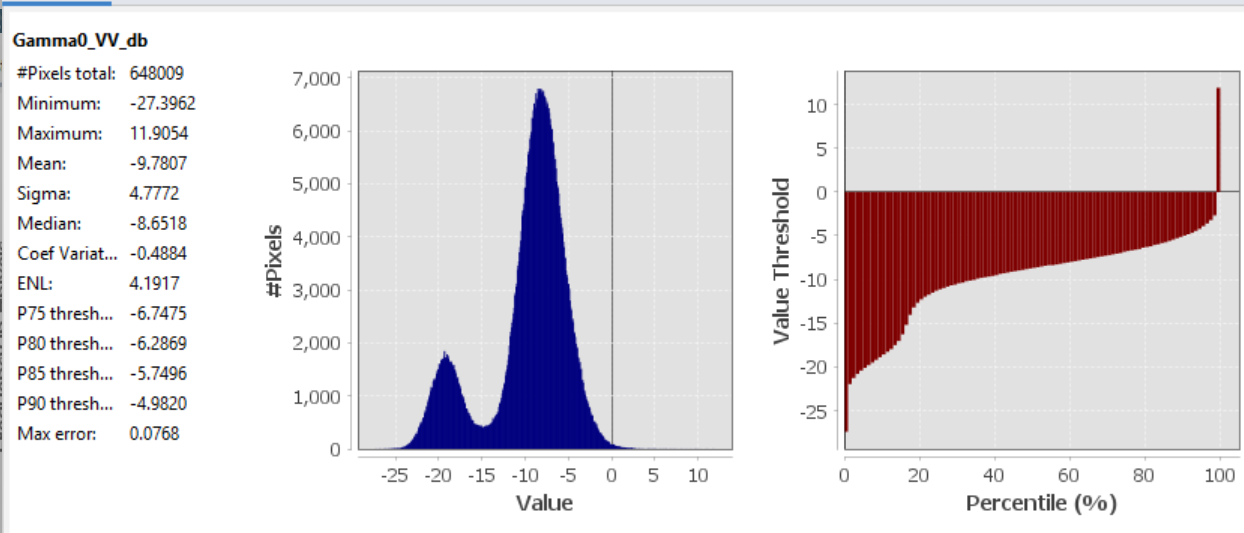

In [68]:
import numpy as np
with rasterio.open(file_path) as src:
    # Read the band data (assuming the first band is in dB)
    band_data = src.read(1)
    # Mask out no-data values (e.g., 0 or other no-data value)
    band_data = np.ma.masked_equal(band_data, 0)  # Masking no-data values
    band_data = np.ma.masked_invalid(band_data)  # Masking NaN values as well


In [70]:
print(f"Min value: {band_data.min()}, Max value: {band_data.max()}")



Min value: 8.826530392980203e-05, Max value: 1.760157585144043


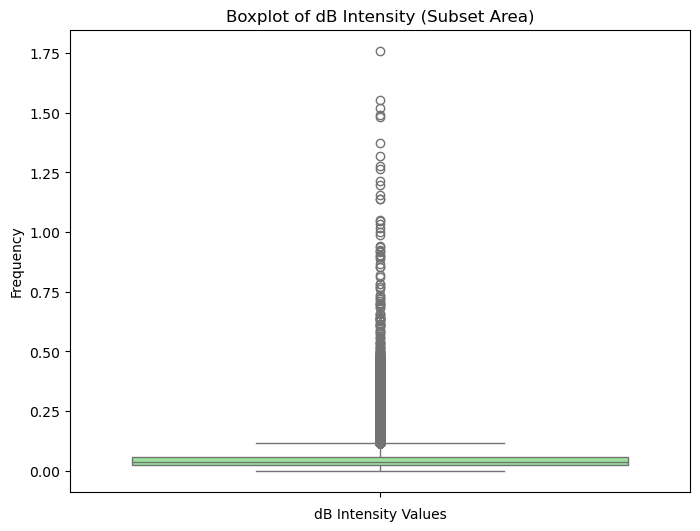

In [72]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.boxplot(data=band_data.flatten(), color='lightgreen')
plt.title('Boxplot of dB Intensity (Subset Area)')
plt.xlabel('dB Intensity Values')
plt.ylabel('Frequency')
plt.show()
s1_image = file_path

### what do we infer from the graph 
- Box is very thin and squished near the bottom
- Most of the pixel intensities (in dB) are clustered very tightly at low values.
- The spread of the majority of the data (the interquartile range, IQR) is very small.
- Lots of outliers.
- Many points scattered far above the box — these are outlier pixels with much higher dB values.
- These outliers are relatively rare compared to the majority of pixels.
- Whiskers are short.
- Suggests that apart from outliers, normal variations are small.

### what it means for the terrain??
- Majority of area: Very low backscatter — could be flat, smooth, or low-vegetation surfaces.<be>

**Sparse but strong backscatter points (outliers):**

- These could be rocks, exposed rough patches, man-made structures, or steep slopes facing the radar directly.
- Or even tree clusters in a generally smoother terrain.

**Highly skewed distribution:**

- Most of the area is homogeneous, but some small regions reflect radar very strongly.

In [76]:
import rasterio
import numpy as np
import cv2
with rasterio.open(file_path) as src:
    s1_image = src.read(1)  # or src.read() for all bands

print("Min:", np.min(s1_image))
print("Max:", np.max(s1_image))
print("Mean:", np.mean(s1_image))


Min: 8.8265304e-05
Max: 1.7601576
Mean: 0.04561942


In [78]:
s1_dB = 10 * np.log10(s1_image)


In [80]:
s1_dB = np.clip(s1_dB, -30, 0)  # SAR values usually fall in this range


In [96]:
s1_norm = cv2.normalize(s1_dB, None, 0, 255, cv2.NORM_MINMAX)
s1_uint8 = s1_norm.astype(np.uint8)
cv2.imwrite(r"E:\s1_normalized.tif", s1_uint8)
# "E:\subset_21_of_subset_19_of_subset_14_of_subset_0_of_S1A_IW_GRDH_1SDV_20240117T021944_20240117T022009_052140_064D65_B55C_Orb_tnr_Cal_Spk_TC.tif"

True

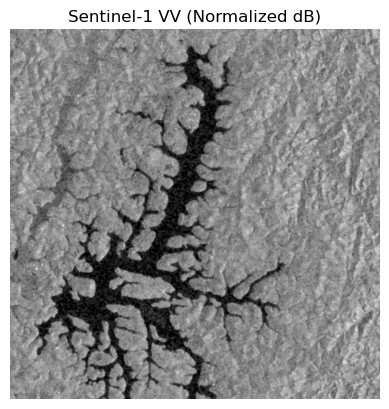

In [98]:
plt.imshow(s1_uint8, cmap='gray')
plt.title("Sentinel-1 VV (Normalized dB)")
plt.axis('off')
plt.show()


- It clearly shows a dendritic network — this is typical of a river or drainage network in a hilly or rugged terrain.
- Bright areas (higher dB) probably represent vegetated hill slopes (stronger backscatter due to vegetation structure).
- Dark areas (low dB) represent water bodies or smooth surfaces (because water scatters radar away, leading to low return).

In [101]:
edges = cv2.Canny(s1_uint8, 50, 150)


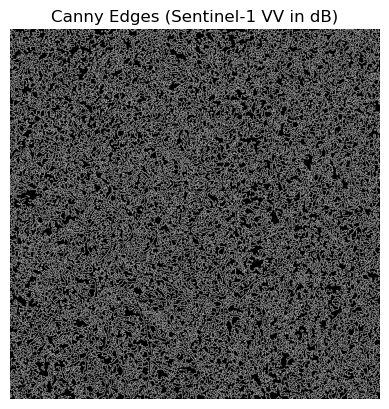

In [103]:
plt.imshow(edges, cmap='gray')
plt.title("Canny Edges (Sentinel-1 VV in dB)")
plt.axis('off')
plt.show()


the above pic shows the canny edge detection in the sentinel dataset, as we can see the canny edge detection for the image is too rough so this also proves that its a hilly terrain apparently the canny detector detects even the noise for the edge so we will apply gaussian blur on this and then redo 
canny edge

C:\Users\Jahanvi\anaconda3\Lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Image shape: (1009, 1009), dtype: uint8


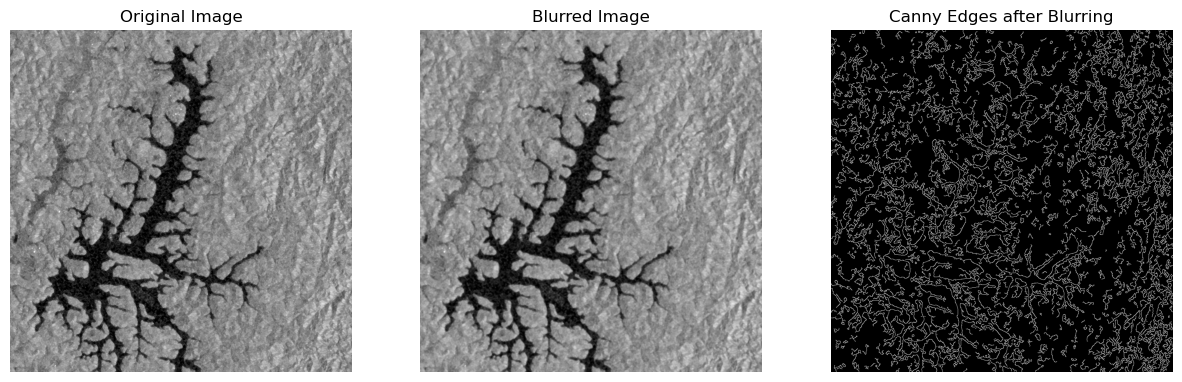

In [133]:
import rasterio
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Read the Sentinel-1 image using rasterio
input_path = r"E:\s1_normalized.tif"

with rasterio.open(input_path) as src:
    img = src.read(1)  # Read the first band (assuming single-band image)
    print(f"Image shape: {img.shape}, dtype: {img.dtype}")

# Step 2: Apply Gaussian Blur
# Convert the image to uint8 for cv2, if it's not already
img_uint8 = img.astype(np.uint8)

# Apply Gaussian Blur (adjust kernel size as needed)
blurred = cv2.GaussianBlur(img_uint8, (5, 5), sigmaX=1.0, sigmaY=1.0)

# Step 3: Apply Canny edge detection
edges = cv2.Canny(blurred, threshold1=50, threshold2=150)

# Step 4: Plot the images
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Blurred Image')
plt.imshow(blurred, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Canny Edges after Blurring')
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.show()


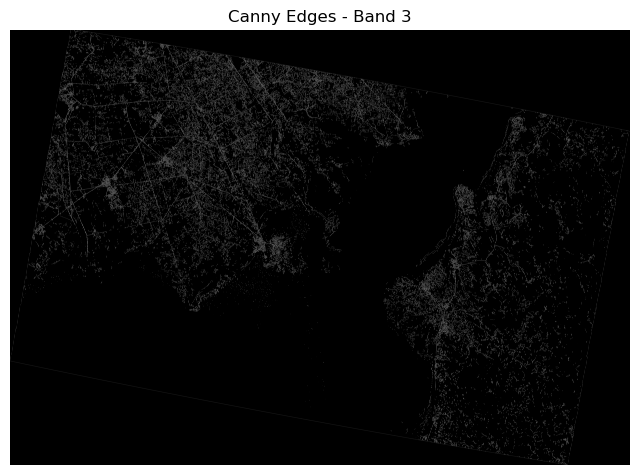

In [114]:
import rasterio
import numpy as np
import cv2
import matplotlib.pyplot as plt

def apply_canny_on_reflectance(image_path, band_index=3, low_threshold=50, high_threshold=150):
    """
    Applies Canny edge detection on a selected band from a reflectance image.
    
    band_index: 1-based (1=Blue, 2=Green, 3=Red, 4=NIR)
    """
    with rasterio.open(image_path) as src:
        band = src.read(band_index)  # Read selected band
        reflectance = band.astype(np.float32)
        
        # Scale reflectance (0–1) to 0–255 uint8
        reflectance_scaled = np.clip(reflectance * 255.0, 0, 255).astype(np.uint8)

        # Apply Canny edge detection
        edges = cv2.Canny(reflectance_scaled, low_threshold, high_threshold)

    # Plot the edge image
    plt.figure(figsize=(8, 6))
    plt.imshow(edges, cmap='gray')
    plt.title(f'Canny Edges - Band {band_index}')
    plt.axis('off')
    plt.show()

# === Usage ===
reflectance_image_path = r"ortho_analytic_reflectance1.tif"
apply_canny_on_reflectance(reflectance_image_path, band_index=3)  # Red band


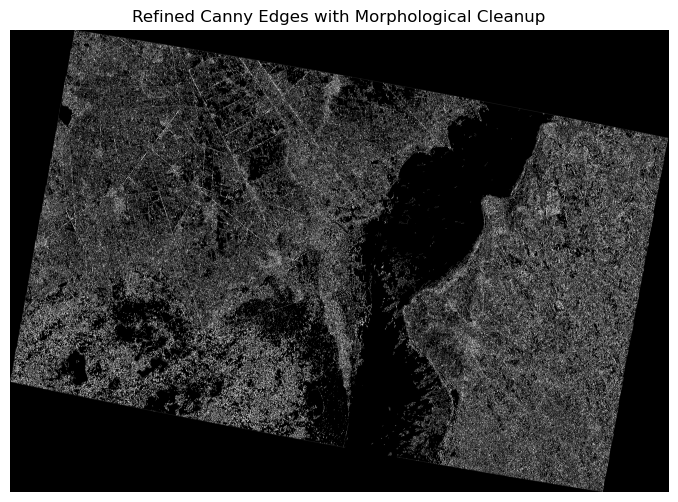

In [115]:
import rasterio
import numpy as np
import cv2
import matplotlib.pyplot as plt

def canny_with_morphology(image_path, blur_ksize=5, low_thresh=10, high_thresh=50):
    with rasterio.open(image_path) as src:
        # Read RGB bands and compute grayscale (PlanetScope: B=1, G=2, R=3)
        blue = src.read(1).astype(np.float32)
        green = src.read(2).astype(np.float32)
        red = src.read(3).astype(np.float32)

        # Grayscale from RGB (weighted)
        gray = 0.2989 * red + 0.5870 * green + 0.1140 * blue
        gray_norm = np.clip(gray * 255.0, 0, 255).astype(np.uint8)

        # Histogram equalization (optional, for contrast)
        gray_eq = cv2.equalizeHist(gray_norm)

        # Gaussian blur
        blurred = cv2.GaussianBlur(gray_eq, (blur_ksize, blur_ksize), 1.0)

        # Canny edge detection
        edges_blur = cv2.Canny(blurred, low_thresh, high_thresh)

        # Morphological operations
        kernel = np.ones((3, 3), np.uint8)
        edges_dilated = cv2.dilate(edges_blur, kernel, iterations=1)
        edges_cleaned = cv2.erode(edges_dilated, kernel, iterations=1)

    # Show final result
    plt.figure(figsize=(10, 6))
    plt.imshow(edges_cleaned, cmap='gray')
    plt.title('Refined Canny Edges with Morphological Cleanup')
    plt.axis('off')
    plt.show()

# === Usage ===
reflectance_image_path = r"ortho_analytic_reflectance1.tif"
canny_with_morphology(reflectance_image_path)


In [116]:
import torchvision.models as models
import torchvision.transforms as transforms
import torch
from PIL import Image
import numpy as np

# Load EfficientNet-B0 without classifier (for feature extraction)
model = models.efficientnet_b0(pretrained=True)
model.eval()


C:\Users\Jahanvi\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Jahanvi\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [117]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])


In [121]:
import os
print(os.path.exists(r"ortho_analytic_reflectance1.tif"))


True


In [119]:

planet_rgb_image = cv2.imread(reflectance_output_path)
planet_rgb_image = cv2.cvtColor(planet_rgb_image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

planet_img_tensor = transform(planet_rgb_image).unsqueeze(0)  # [1, 3, 224, 224]


error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [123]:
import rasterio
import numpy as np

# 1. Read image with rasterio
with rasterio.open(reflectance_output_path) as src:
    img = src.read()  # shape will be [bands, height, width]

# 2. Check if image has 3 bands (for RGB)
if img.shape[0] >= 3:
    # If more than 3 bands (e.g., 4 bands), take first 3
    planet_rgb_image = np.stack([img[0], img[1], img[2]], axis=-1)  # [H, W, 3]
else:
    raise ValueError("The image does not have enough bands for RGB!")

# 3. Optional: Normalize if needed (if pixel values are not 0-255)
if planet_rgb_image.dtype != np.uint8:
    # Stretching to 0-255 if needed
    planet_rgb_image = (planet_rgb_image - planet_rgb_image.min()) / (planet_rgb_image.max() - planet_rgb_image.min())
    planet_rgb_image = (planet_rgb_image * 255).astype(np.uint8)

# 4. Now apply your transform
planet_img_tensor = transform(planet_rgb_image).unsqueeze(0)  # [1, 3, 224, 224]

print("Final tensor shape:", planet_img_tensor.shape)


Final tensor shape: torch.Size([1, 3, 224, 224])


In [125]:
# Normalize dB image to [0, 255] and convert to uint8
s1_dB_normalized = cv2.normalize(s1_dB, None, 0, 255, cv2.NORM_MINMAX)
s1_image_uint8 = s1_dB_normalized.astype(np.uint8)

s1_rgb = cv2.cvtColor(s1_image_uint8, cv2.COLOR_GRAY2RGB)
s1_tensor = transform(s1_rgb).unsqueeze(0)


In [127]:
# Lets extract features 
with torch.no_grad():
    planet_features = model.features(planet_img_tensor)
    s1_features = model.features(s1_tensor)

print("Planet feature map shape:", planet_features.shape)
print("S1 feature map shape:", s1_features.shape)


Planet feature map shape: torch.Size([1, 1280, 7, 7])
S1 feature map shape: torch.Size([1, 1280, 7, 7])


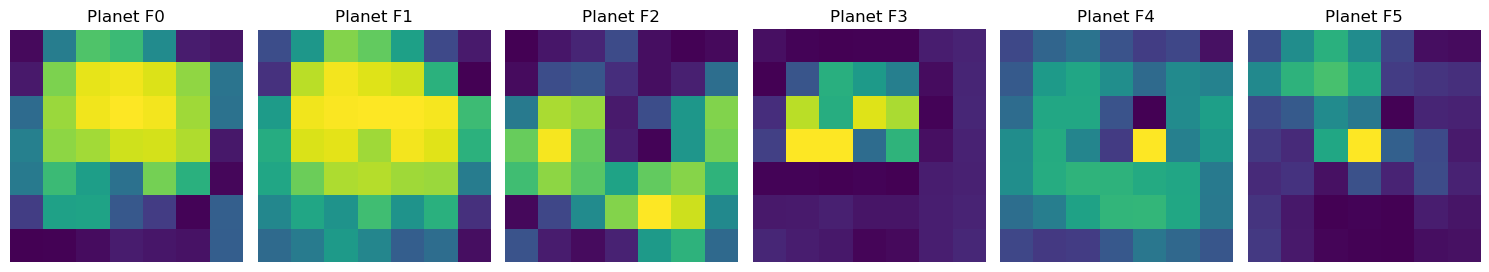

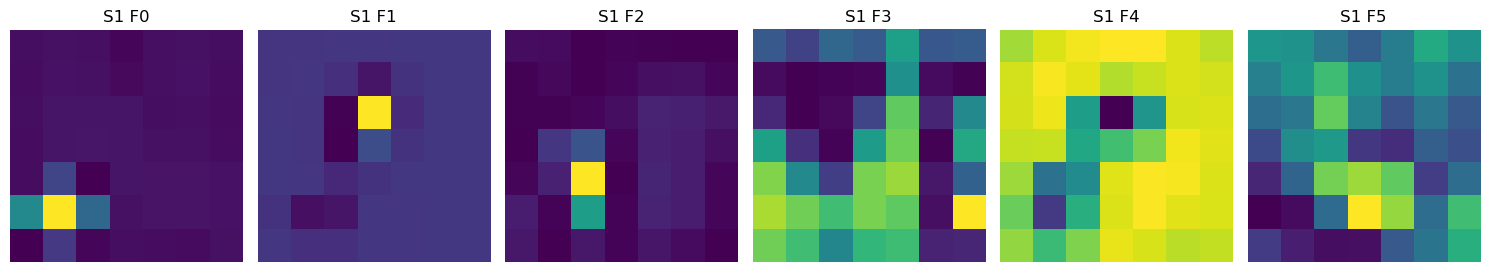

In [129]:
import matplotlib.pyplot as plt

def plot_feature_maps(feat_tensor, title_prefix):
    fmap = feat_tensor.squeeze(0).cpu().numpy()  # [C, H, W]
    plt.figure(figsize=(15, 5))
    for i in range(6):  # First 6 channels
        plt.subplot(1, 6, i+1)
        plt.imshow(fmap[i], cmap='viridis')
        plt.title(f"{title_prefix} F{i}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_feature_maps(planet_features, "Planet")
plot_feature_maps(s1_features, "S1")


### **Planet Features**
- **F1 & F2**: These filters exhibit widespread activations, suggesting sensitivity to large, homogeneous regions—possibly vegetation or open fields. The bright yellow areas indicate strong texture consistency or reflectance, meaning these features may highlight well-lit surfaces with minimal variation.
- **F3**: Displays a concentrated activation in a specific region, which suggests sensitivity to man-made structures or significant terrain features such as roads or dense urban areas. The suppression in surrounding regions implies high responsiveness to edges and sharp contrasts.
- **F5**: Isolated bright regions indicate potential edge or boundary detection. This feature may capture objects with high contrast differences, such as rooftops, vehicles, or shadowed areas. The selective activation suggests it is looking for defining elements in the landscape.

### **Sentinel-1 Features**
- **F1**: Shows a strong, uniform response across the image—likely detecting large-scale flat surfaces with high radar reflectance. This could correlate with wet agricultural fields, built-up areas, or smooth terrain.
- **F2 & F3**: Present more localized responses, highlighting variations in surface roughness. These filters may be detecting roads, terrain discontinuities, or linear features like canals and land-use boundaries.
- **F5**: Displays a bright activation in the bottom-left, suggesting the presence of a highly reflective object—possibly a metallic structure, urban development, or another surface with strong radar return.

### **Comparing PlanetScope and Sentinel-1 Features**
- **PlanetScope features** emphasize color, brightness, and texture, making them highly interpretable in visual imagery.
- **Sentinel-1 features** focus on structural, moisture-related, and roughness variations—providing insights that optical sensors may not capture.
- **Complementary Insights**: PlanetScope gives a natural appearance-based understanding, whereas Sentinel-1 provides deeper structure-based detail, making them valuable for joint analysis.

